In [1]:
# Import the packages required for this tutorial

import numpy as np 
import matplotlib as mpl
import matplotlib.pyplot as plt

import py21cmfast as p21c # To run 21cmFirstCLASS (21cmFAST)
from py21cmfast import plotting # For plotting global signals, coeval boxes, lightcone boxes and power spectra
import py21cmfast.power_spectrum as ps # Calculate power spectrum from the lightcone
from py21cmfast.inputs import global_params # Useful in this tutorial to plot the initial conditions for the simulation
from scipy.interpolate import interp1d
from functools import partial

from scipy.special import erfc
from classy import Class

-----------------------------------------------------
SarahLibanore: developed f_nl, C files updated with IC and fcoll in Lidz approximation and DAlosio on 09/22/2025
-----------------------------------------------------


In [2]:
plt.rcParams.update({"text.usetex": True, "font.family": "Times new roman"}) # Use latex fonts

In [3]:
colors =  ['#377eb8', '#ff7f00', '#4daf4a',
           '#f781bf', '#a65628', '#984ea3',
           '#999999', '#e41a1c', '#dede00']

mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors) # Set the color palette as default

In [4]:
flag_options = {"USE_MINI_HALOS": False, } # if False, popIII stars are not included - Note: if set to True, the runtime increases significantly!

In [5]:
astro_params = {"F_STAR10": -1.25, # star formation efficiency (atomic cooling galaxies) for pivot mass 1e10 Msun (log10)
                "ALPHA_STAR": 0.5, # slope of the dependency of star formation efficiency on the host halo mass 
                "F_ESC10": -1.35, # escape fraction of Lyman photons into the IGM for pivot mass 1e10 Msun (log10)
                "ALPHA_ESC": -0.3, # slope of the dependency of escape fraction on the host halo mass 
                "L_X": 40.5, # X-ray luminosity (log10)
}


In [6]:
global_quantities = ("brightness_temp", # brightness temperature
                     "Tk_box", # kinetic temperature
                     "Ts_box", # spin temperature
                     "xH_box", # neutral hydrogen fraction
                     "J_Lya_box", # Lyman alpha flux - new feature in 21cmFirstCLASS! 
                     "x_e_box") # free electron fraction

coeval_quantities = ["density", # matter density fluctuations 
                     "brightness_temp",
                     "xH_box"]

input_coeval_redshifts = [6., 
                          10., 
                          15.]

lightcone_quantities = ("brightness_temp",
                        "density",
                        "xH_box")

In [7]:
cosmo_params_fNL0 = {"hlittle": 0.6736, # hubble parameter
                "OMb": 0.0493, # baryon density
                "OMm": 0.3153, # matter (CDM+baryon) density
                "A_s": 2.1e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":0., # to test matching with old case
                }

cosmo_params_fNL = {"hlittle": 0.6736, # hubble parameter
                "OMb": 0.0493, # baryon density
                "OMm": 0.3153, # matter (CDM+baryon) density
                "A_s": 2.1e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":300., # to test matching with old case
                }

cosmo_params_mfNL = {"hlittle": 0.6736, # hubble parameter
                "OMb": 0.0493, # baryon density
                "OMm": 0.3153, # matter (CDM+baryon) density
                "A_s": 2.1e-9, # amplitude of the primordial fluctuations
                "POWER_INDEX": 0.9649, # spectral index of the primordial spectrum
                "tau_reio": 0.0544, # optical depth to reionization
                "F_NL":-300., # to test matching with old case
                }


## 1) Test initial conditions

In [8]:
user_params = {"BOX_LEN": 100, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": 25, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":False, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":False,# use non gaussian field in collapsed fraction
               } # 

user_params_NG_IC = {"BOX_LEN": 100, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": 25, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "EXTRA_DIM_FNL":1.5,
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":True, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":False,# use non gaussian field in collapsed fraction
               } # 

user_params_NG_fnl = {"BOX_LEN": 100, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": 25, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "EXTRA_DIM_FNL":1.5,
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":True, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":True,# use non gaussian field in collapsed fraction
               } # 


user_params_bigbox = {"BOX_LEN": 200, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": 25, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":False, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":False,# use non gaussian field in collapsed fraction
               } # 

user_params_NG_IC_bigbox = {"BOX_LEN": 200, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": 25, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "EXTRA_DIM_FNL":1.5,
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":True, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":False,# use non gaussian field in collapsed fraction
               } # 

user_params_smallbox = {"BOX_LEN": 800, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": 100, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":False, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":False,# use non gaussian field in collapsed fraction
               } # 

user_params_NG_IC_smallbox = {"BOX_LEN": 800, # size of the simulated box (in comoving Mpc) 
               "HII_DIM": 100, # number of cells along each axis of the coeval box - Note: more cells means longer runtime! 
               "EXTRA_DIM_FNL":1.5,
               "N_THREADS": 6, # the amount of processors the code uses in parallelization
               "NON_GAUSS_IC":True, # use non gaussian field in initial conditions
               "NON_GAUSS_FCOLL":False,# use non gaussian field in collapsed fraction
               } # 



In [9]:
# original = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
#                                random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, 17due to cosmic variance. 
#                                regenerate = True, # create new data even if cached are found
#                                write = False, # whether or no to save cached files
#                                user_params = user_params,
#                                astro_params = astro_params, 
#                                flag_options = flag_options,
#                                cosmo_params = cosmo_params_fNL0,
#                                global_quantities = global_quantities,
#                                save_coeval_quantities = coeval_quantities,
#                                save_coeval_redshifts = input_coeval_redshifts,
#                                lightcone_quantities = lightcone_quantities) ; 

In [10]:
# original_bigbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
#                                random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, 17due to cosmic variance. 
#                                regenerate = True, # create new data even if cached are found
#                                write = False, # whether or no to save cached files
#                                user_params = user_params_bigbox,
#                                astro_params = astro_params, 
#                                flag_options = flag_options,
#                                cosmo_params = cosmo_params_fNL0,
#                                global_quantities = global_quantities,
#                                save_coeval_quantities = coeval_quantities,
#                                save_coeval_redshifts = input_coeval_redshifts,
#                                lightcone_quantities = lightcone_quantities) ; 

In [11]:
# original_smallbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
#                                random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, 17due to cosmic variance. 
#                                regenerate = True, # create new data even if cached are found
#                                write = False, # whether or no to save cached files
#                                user_params = user_params_smallbox,
#                                astro_params = astro_params, 
#                                flag_options = flag_options,
#                                cosmo_params = cosmo_params_fNL0,
#                                global_quantities = global_quantities,
#                                save_coeval_quantities = coeval_quantities,
#                                save_coeval_redshifts = input_coeval_redshifts,
#                                lightcone_quantities = lightcone_quantities) ; 

In [12]:
fnl0 = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_fNL0,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 


Now running CLASS...
Now generating initial boxes...
potential=4.715396e-05
delta phi^2=-3.759685e-09
boxes->hires_density=1.257610e+00


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:17<00:00,  1.08redshift/s]


Now evaluating tau to reionization and re-running CLASS...


In [13]:
fnl0_bigbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC_bigbox,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_fNL0,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 


Now running CLASS...
Now generating initial boxes...
potential=9.546210e-05
delta phi^2=-1.540893e-08
boxes->hires_density=9.160033e-01


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:12<00:00,  1.16redshift/s]


Now evaluating tau to reionization and re-running CLASS...


In [14]:
fnl0_smallbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC_smallbox,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_fNL0,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 


Now running CLASS...
Now generating initial boxes...
potential=-1.261546e-04
delta phi^2=-8.131419e-09
boxes->hires_density=-4.113652e+00


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [09:56<00:00,  7.10s/redshift]


Now evaluating tau to reionization and re-running CLASS...


Text(0.5, 0, '')

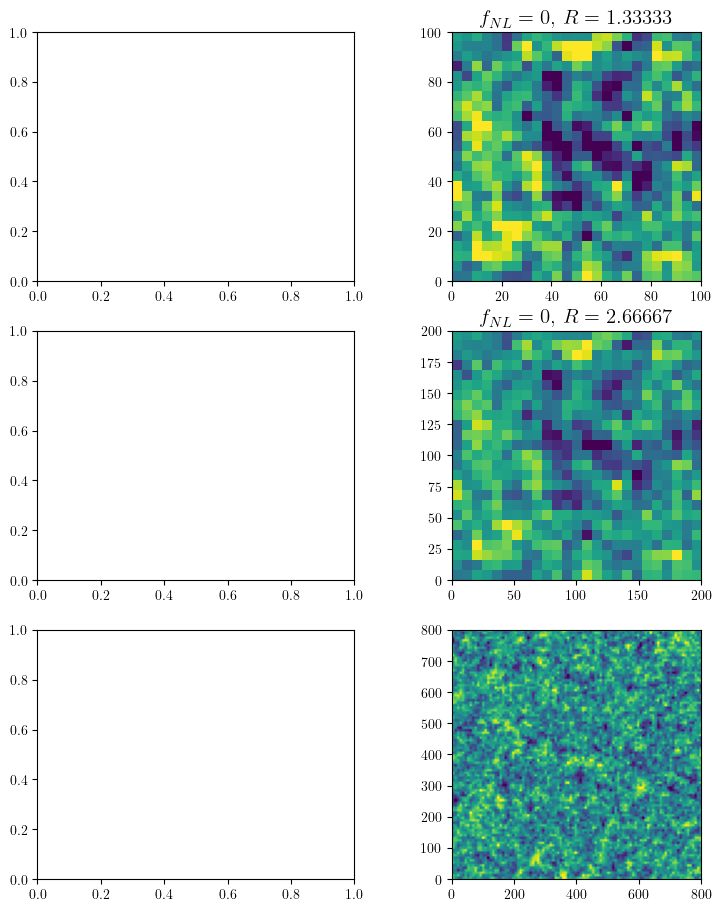

In [15]:
fig, ax = plt.subplots(3, 2, figsize=(9, 11))

nslice = 10

redshift = 15.
coeval_redshifts = list(fnl0.coeval_boxes.keys())
coeval_redshift = coeval_redshifts[np.argmin(np.abs(redshift - np.array(coeval_redshifts)))]

# im = ax[0,0].imshow(original.coeval_boxes[coeval_redshift]['density'][nslice],cmap='viridis',vmin=-0.3,vmax=0.3,extent=(0,100,0,100))
# ax[0,0].set_title(r'$Original,\,R=%g$'%(user_params['BOX_LEN']/(user_params['HII_DIM']*3)),fontsize=15)

im = ax[0,1].imshow(fnl0.coeval_boxes[coeval_redshift]['density'][nslice],cmap='viridis',vmin=-0.3,vmax=0.3,extent=(0,100,0,100))
ax[0,1].set_title(r'$f_{NL}=0,\,R=%g$'%(user_params_NG_IC['BOX_LEN']/(user_params_NG_IC['HII_DIM']*3)),fontsize=15)

# im = ax[1,0].imshow(original_bigbox.coeval_boxes[coeval_redshift]['density'][nslice],cmap='viridis',vmin=-0.3,vmax=0.3,extent=(0,user_params_bigbox['BOX_LEN'],0,user_params_bigbox['BOX_LEN']))
# ax[1,0].set_title(r'$Original,\,R=%g$'%(user_params_bigbox['BOX_LEN']/(user_params_bigbox['HII_DIM']*3)),fontsize=15)

im = ax[1,1].imshow(fnl0_bigbox.coeval_boxes[coeval_redshift]['density'][nslice],cmap='viridis',vmin=-0.3,vmax=0.3,extent=(0,user_params_bigbox['BOX_LEN'],0,user_params_bigbox['BOX_LEN']))
ax[1,1].set_title(r'$f_{NL}=0,\,R=%g$'%(user_params_bigbox['BOX_LEN']/(user_params_bigbox['HII_DIM']*3)),fontsize=15)

# im = ax[2,0].imshow(original_smallbox.coeval_boxes[coeval_redshift]['density'][nslice],cmap='viridis',vmin=-0.3,vmax=0.3,extent=(0,user_params_smallbox['BOX_LEN'],0,user_params_smallbox['BOX_LEN']))
# ax[1,0].set_title(r'$Original,\,R=%g$'%(user_params_smallbox['BOX_LEN']/(user_params_smallbox['HII_DIM']*3)),fontsize=15)

im = ax[2,1].imshow(fnl0_smallbox.coeval_boxes[coeval_redshift]['density'][nslice],cmap='viridis',vmin=-0.3,vmax=0.3,extent=(0,user_params_smallbox['BOX_LEN'],0,user_params_smallbox['BOX_LEN']))
ax[1,1].set_title(r'$f_{NL}=0,\,R=%g$'%(user_params_smallbox['BOX_LEN']/(user_params_smallbox['HII_DIM']*3)),fontsize=15)

# Omit ylabels at the two rightmost plots
ax[0,1].set_ylabel('')
ax[1,1].set_ylabel('')
ax[0,0].set_xlabel('')
ax[0,1].set_xlabel('')


In [16]:
fnl100 = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_fNL,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 

Now running CLASS...
Now generating initial boxes...
potential=4.715396e-05
delta phi^2=-3.759685e-09
boxes->hires_density=1.271966e+00


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:30<00:00,  1.07s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [17]:
# fnl100_all = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
#                                random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
#                                regenerate = True, # create new data even if cached are found
#                                write = False, # whether or no to save cached files
#                                user_params = user_params_NG_fnl ,
#                                astro_params = astro_params, 
#                                flag_options = flag_options,
#                                cosmo_params = cosmo_params_fNL,
#                                global_quantities = global_quantities,
#                                save_coeval_quantities = coeval_quantities,
#                                save_coeval_redshifts = input_coeval_redshifts,
#                                lightcone_quantities = lightcone_quantities) ; 

In [18]:
fnl100_bigbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC_bigbox,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_fNL,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 

Now running CLASS...
Now generating initial boxes...
potential=9.546210e-05
delta phi^2=-1.540893e-08
boxes->hires_density=9.073706e-01


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:11<00:00,  1.17redshift/s]


Now evaluating tau to reionization and re-running CLASS...


In [19]:
fnl100_smallbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC_smallbox,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_fNL,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 

Now running CLASS...
Now generating initial boxes...
potential=-1.261546e-04
delta phi^2=-8.131419e-09
boxes->hires_density=-4.285595e+00


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [10:34<00:00,  7.55s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [20]:
fnlm100 = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_mfNL,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 

Now running CLASS...
Now generating initial boxes...
potential=4.715396e-05
delta phi^2=-3.759685e-09
boxes->hires_density=1.243254e+00


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:30<00:00,  1.08s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [21]:
# fnlm100_all = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
#                                random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
#                                regenerate = True, # create new data even if cached are found
#                                write = False, # whether or no to save cached files
#                                user_params = user_params_NG_fnl,
#                                astro_params = astro_params, 
#                                flag_options = flag_options,
#                                cosmo_params = cosmo_params_mfNL,
#                                global_quantities = global_quantities,
#                                save_coeval_quantities = coeval_quantities,
#                                save_coeval_redshifts = input_coeval_redshifts,
#                                lightcone_quantities = lightcone_quantities) ; 

In [22]:
fnlm100_bigbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC_bigbox,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_mfNL,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 

Now running CLASS...
Now generating initial boxes...
potential=9.546210e-05
delta phi^2=-1.540893e-08
boxes->hires_density=9.246350e-01


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [01:16<00:00,  1.09redshift/s]


Now evaluating tau to reionization and re-running CLASS...


In [23]:
fnlm100_smallbox = p21c.run_lightcone(redshift = 6., # minimum redshift at which the simulation will stop
                               random_seed = 1, # numerical seed -- if None, each run will produce different initial conditions, with the same cosmological power spectrum but different spatial realization. You need to specify the random seed to coherently compare two different runs, due to cosmic variance. 
                               regenerate = True, # create new data even if cached are found
                               write = False, # whether or no to save cached files
                               user_params = user_params_NG_IC_smallbox,
                               astro_params = astro_params, 
                               flag_options = flag_options,
                               cosmo_params = cosmo_params_mfNL,
                               global_quantities = global_quantities,
                               save_coeval_quantities = coeval_quantities,
                               save_coeval_redshifts = input_coeval_redshifts,
                               lightcone_quantities = lightcone_quantities) ; 

Now running CLASS...
Now generating initial boxes...
potential=-1.261546e-04
delta phi^2=-8.131419e-09
boxes->hires_density=-3.941710e+00


21cmFAST (cosmic dawn): 100%|██████████| 84/84 [09:51<00:00,  7.04s/redshift]


Now evaluating tau to reionization and re-running CLASS...


In [24]:
freq_bands_boundaries = np.arange(50.,225.+8.,8.); freq_bands_boundaries[-1] = 225.

# power_spectrum_original = ps.lightcone_power_spectrum(original,
#                                                       kind='density',
#                                                   freq_bands_boundaries = freq_bands_boundaries) ; 

# power_spectrum_original_bigbox = ps.lightcone_power_spectrum(original_bigbox,
#                                                       kind='density',
#                                                   freq_bands_boundaries = freq_bands_boundaries) ; 

# power_spectrum_original_smallbox = ps.lightcone_power_spectrum(original_smallbox,
#                                                       kind='density',
#                                                   freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnl0 = ps.lightcone_power_spectrum(fnl0,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnl0_bigbox = ps.lightcone_power_spectrum(fnl0_bigbox,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnl0_smallbox = ps.lightcone_power_spectrum(fnl0_smallbox,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnl100 = ps.lightcone_power_spectrum(fnl100,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

# power_spectrum_fnl100_all = ps.lightcone_power_spectrum(fnl100_all,
#                                                       kind='density',
#                                                   freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnl100_bigbox = ps.lightcone_power_spectrum(fnl100_bigbox,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnl100_smallbox = ps.lightcone_power_spectrum(fnl100_smallbox,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnlm100 = ps.lightcone_power_spectrum(fnlm100,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

# power_spectrum_fnlm100_all = ps.lightcone_power_spectrum(fnlm100_all,
#                                                       kind='density',
#                                                   freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnlm100_bigbox = ps.lightcone_power_spectrum(fnlm100_bigbox,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 

power_spectrum_fnlm100_smallbox = ps.lightcone_power_spectrum(fnlm100_smallbox,
                                                      kind='density',
                                                  freq_bands_boundaries = freq_bands_boundaries) ; 



Text(0.5, 1.0, '$L_{\\rm box}=800\\,{\\rm Mpc}$$,\\,N_{\\rm box}=300$')

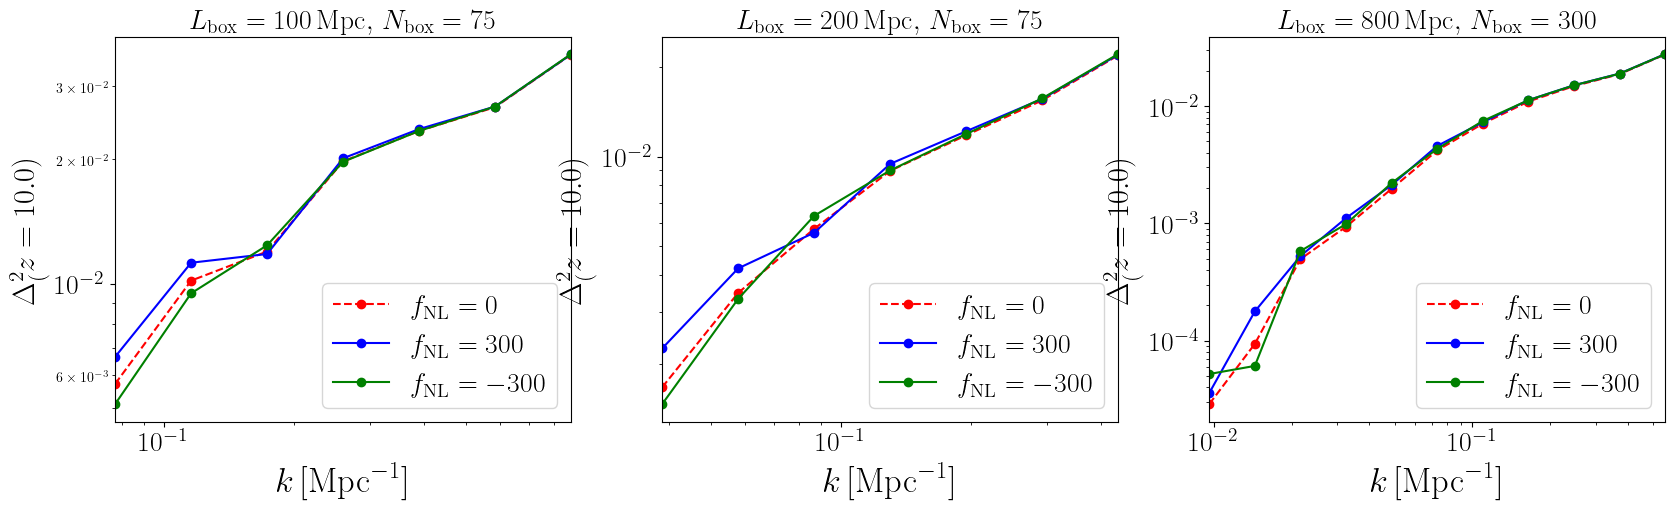

In [25]:
fig, ax = plt.subplots(1,3,figsize=(20,5))

# plotting.plot_1d_power_spectrum(power_spectrum_original,
#                                           z =10., # scale in units 1/Mpc
#                                           # you can specify the following properties for your plot; if None (or omitted) defaults are used
#                                           smooth=None, # the curve can be smoothed by interpolating in intermediate points
#                                           xlabel = None,
#                                           ylabel = None,
#                                           xlog = True, # linear scale on the x-axis by default
#                                           ylog = True, # log scale on the y-axis by default
#                                           # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
#                                           color = 'k',
#                                           ls='-',
#                                           ax = ax[0],
#                                           marker='o')

plotting.plot_1d_power_spectrum(power_spectrum_fnl0,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'r',
                                          ls='--',
                                          ax=ax[0],
                                          marker='o',label=r'$f_{\rm NL}=0$')

plotting.plot_1d_power_spectrum(power_spectrum_fnl100,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'b',
                                          ls='-',
                                          ax=ax[0],
                                          marker='o',label=r'$f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'] )

plotting.plot_1d_power_spectrum(power_spectrum_fnlm100,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'g',
                                          ls='-',
                                          ax=ax[0],
                                          marker='o',
                                          label=r'$f_{\rm NL}=%g$'%cosmo_params_mfNL['F_NL'] )


# plotting.plot_1d_power_spectrum(power_spectrum_original_bigbox,
#                                           z =10., # scale in units 1/Mpc
#                                           # you can specify the following properties for your plot; if None (or omitted) defaults are used
#                                           smooth=None, # the curve can be smoothed by interpolating in intermediate points
#                                           xlabel = None,
#                                           ylabel = None,
#                                           xlog = True, # linear scale on the x-axis by default
#                                           ylog = True, # log scale on the y-axis by default
#                                           # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
#                                           color = 'k',
#                                           ls='-',
#                                           ax = ax[1],
#                                           marker='o')

plotting.plot_1d_power_spectrum(power_spectrum_fnl0_bigbox,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'r',
                                          ls='--',
                                          ax=ax[1],
                                          marker='o',label=r'$f_{\rm NL}=0$')

plotting.plot_1d_power_spectrum(power_spectrum_fnl100_bigbox,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'b',
                                          ls='-',
                                          ax=ax[1],
                                          marker='o',label=r'$f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'] )

plotting.plot_1d_power_spectrum(power_spectrum_fnlm100_bigbox,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'g',
                                          ls='-',
                                          ax=ax[1],
                                          marker='o',
                                          label=r'$f_{\rm NL}=%g$'%cosmo_params_mfNL['F_NL'] )

# plotting.plot_1d_power_spectrum(power_spectrum_original_smallbox,
#                                           z =10., # scale in units 1/Mpc
#                                           # you can specify the following properties for your plot; if None (or omitted) defaults are used
#                                           smooth=None, # the curve can be smoothed by interpolating in intermediate points
#                                           xlabel = None,
#                                           ylabel = None,
#                                           xlog = True, # linear scale on the x-axis by default
#                                           ylog = True, # log scale on the y-axis by default
#                                           # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
#                                           color = 'k',
#                                           ls='-',
#                                           ax = ax[2],
#                                           marker='o')

plotting.plot_1d_power_spectrum(power_spectrum_fnl0_smallbox,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'r',
                                          ls='--',
                                          ax=ax[2],
                                          marker='o',label=r'$f_{\rm NL}=0$')

plotting.plot_1d_power_spectrum(power_spectrum_fnl100_smallbox,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'b',
                                          ls='-',
                                          ax=ax[2],
                                          marker='o',label=r'$f_{\rm NL}=%g$'%cosmo_params_fNL['F_NL'] )

plotting.plot_1d_power_spectrum(power_spectrum_fnlm100_smallbox,
                                          z=10., # scale in units 1/Mpc
                                          # you can specify the following properties for your plot; if None (or omitted) defaults are used
                                          smooth=None, # the curve can be smoothed by interpolating in intermediate points
                                          xlabel = None,
                                          ylabel = None,
                                          xlog = True, # linear scale on the x-axis by default
                                          ylog = True, # log scale on the y-axis by default
                                          # Note that this function accepts all the arguments of 'matplotlib.pyplot.plot'!
                                          color = 'g',
                                          ls='-',
                                          ax=ax[2],
                                          marker='o',
                                          label=r'$f_{\rm NL}=%g$'%cosmo_params_mfNL['F_NL'] )

ax[0].set_title(r'$L_{\rm box}=%g\,{\rm Mpc}$'%user_params['BOX_LEN'] +r'$,\,N_{\rm box}=%g$'%(user_params['HII_DIM']*3),fontsize=20)
ax[1].set_title(r'$L_{\rm box}=%g\,{\rm Mpc}$'%user_params_bigbox['BOX_LEN'] +r'$,\,N_{\rm box}=%g$'%(user_params_bigbox['HII_DIM']*3),fontsize=20)
ax[2].set_title(r'$L_{\rm box}=%g\,{\rm Mpc}$'%user_params_smallbox['BOX_LEN'] +r'$,\,N_{\rm box}=%g$'%(user_params_smallbox['HII_DIM']*3),fontsize=20)

# ax[0].set_xlim(1e-3,1)
# ax[1].set_xlim(1e-3,1)
# ax[2].set_xlim(1e-3,1)


Text(0.5, 0, '')

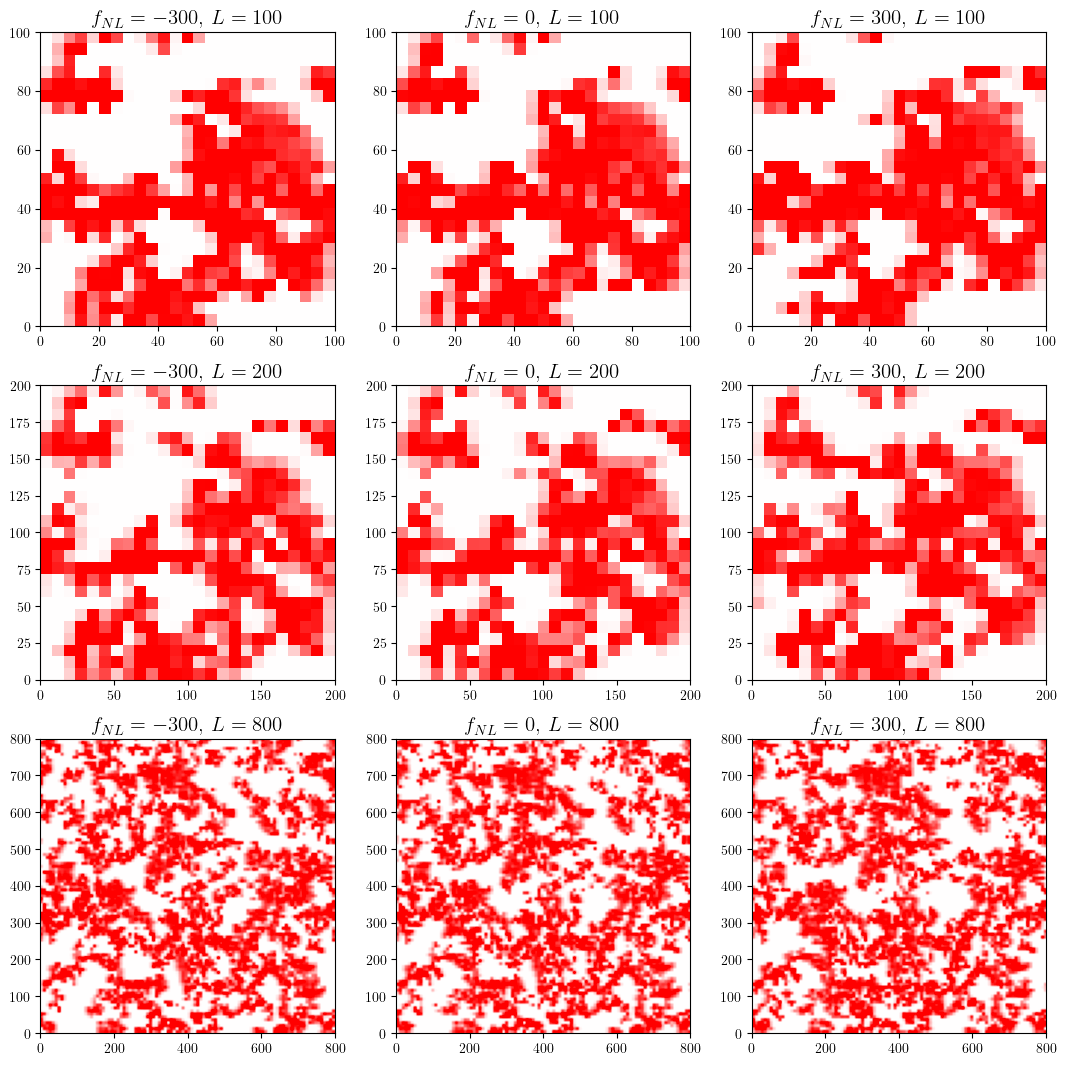

In [29]:
fig, ax = plt.subplots(3, 3, figsize=(13, 13))

nslice = 5
redshift = 7.
coeval_redshifts = list(fnl0.coeval_boxes.keys())
coeval_redshift = coeval_redshifts[np.argmin(np.abs(redshift - np.array(coeval_redshifts)))]

im = ax[0,0].imshow(fnlm100.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC['BOX_LEN'],0,user_params_NG_IC['BOX_LEN']))
ax[0,0].set_title(r'$f_{NL}=%g$'%cosmo_params_mfNL['F_NL'] + r'$,\,L=%g$'%user_params_NG_IC['BOX_LEN'],fontsize=15)

im = ax[0,1].imshow(fnl0.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC['BOX_LEN'],0,user_params_NG_IC['BOX_LEN']))
ax[0,1].set_title(r'$f_{NL}=0$' + r'$,\,L=%g$'%user_params_NG_IC['BOX_LEN'],fontsize=15)

im = ax[0,2].imshow(fnl100.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC['BOX_LEN'],0,user_params_NG_IC['BOX_LEN']))
ax[0,2].set_title(r'$f_{NL}=%g$'%cosmo_params_fNL['F_NL'] + r'$,\,L=%g$'%user_params_NG_IC['BOX_LEN'],fontsize=15)

im = ax[1,0].imshow(fnlm100_bigbox.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC_bigbox['BOX_LEN'],0,user_params_NG_IC_bigbox['BOX_LEN']))
ax[1,0].set_title(r'$f_{NL}=%g$'%cosmo_params_mfNL['F_NL'] + r'$,\,L=%g$'%user_params_NG_IC_bigbox['BOX_LEN'],fontsize=15)

im = ax[1,1].imshow(fnl0_bigbox.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC_bigbox['BOX_LEN'],0,user_params_NG_IC_bigbox['BOX_LEN']))
ax[1,1].set_title(r'$f_{NL}=0$' + r'$,\,L=%g$'%user_params_NG_IC_bigbox['BOX_LEN'],fontsize=15)

im = ax[1,2].imshow(fnl100_bigbox.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC_bigbox['BOX_LEN'],0,user_params_NG_IC_bigbox['BOX_LEN']))
ax[1,2].set_title(r'$f_{NL}=%g$'%cosmo_params_fNL['F_NL'] + r'$,\,L=%g$'%user_params_NG_IC_bigbox['BOX_LEN'],fontsize=15)

im = ax[2,0].imshow(fnlm100_smallbox.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC_smallbox['BOX_LEN'],0,user_params_NG_IC_smallbox['BOX_LEN']))
ax[2,0].set_title(r'$f_{NL}=%g$'%cosmo_params_mfNL['F_NL'] + r'$,\,L=%g$'%user_params_NG_IC_smallbox['BOX_LEN'],fontsize=15)

im = ax[2,1].imshow(fnl0_smallbox.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC_smallbox['BOX_LEN'],0,user_params_NG_IC_smallbox['BOX_LEN']))
ax[2,1].set_title(r'$f_{NL}=0$' + r'$,\,L=%g$'%user_params_NG_IC_smallbox['BOX_LEN'],fontsize=15)

im = ax[2,2].imshow(fnl100_smallbox.coeval_boxes[coeval_redshift]['brightness_temp'][nslice],cmap='bwr',vmin=-10,vmax=10,extent=(0,user_params_NG_IC_smallbox['BOX_LEN'],0,user_params_NG_IC_smallbox['BOX_LEN']))
ax[2,2].set_title(r'$f_{NL}=%g$'%cosmo_params_fNL['F_NL'] + r'$,\,L=%g$'%user_params_NG_IC_smallbox['BOX_LEN'],fontsize=15)


# Omit ylabels at the two rightmost plots
ax[0,1].set_ylabel('')
ax[0,2].set_ylabel('') 
ax[1,1].set_ylabel('')
ax[1,2].set_ylabel('')
ax[0,0].set_xlabel('')
ax[0,1].set_xlabel('')
ax[0,2].set_xlabel('')  

(4.0, 15.0)

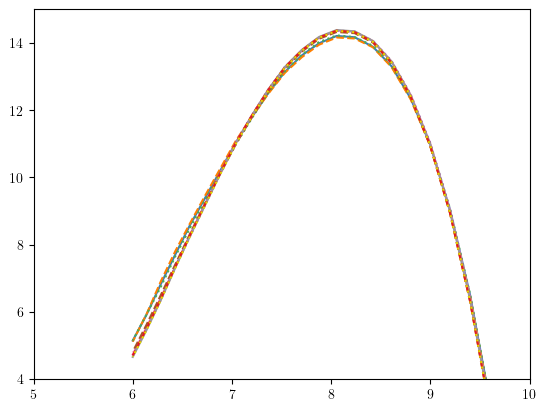

In [27]:
plt.plot(fnl0.node_redshifts,fnl0.global_quantities['brightness_temp'])
plt.plot(fnl100.node_redshifts,fnl100.global_quantities['brightness_temp'],'--')
plt.plot(fnlm100.node_redshifts,fnlm100.global_quantities['brightness_temp'],':')

plt.plot(fnl0_bigbox.node_redshifts,fnl0_bigbox.global_quantities['brightness_temp'])
plt.plot(fnl100_bigbox.node_redshifts,fnl100_bigbox.global_quantities['brightness_temp'],'--')
plt.plot(fnlm100_bigbox.node_redshifts,fnlm100_bigbox.global_quantities['brightness_temp'],':')

plt.plot(fnl0_smallbox.node_redshifts,fnl0_smallbox.global_quantities['brightness_temp'])
plt.plot(fnl100_smallbox.node_redshifts,fnl100_smallbox.global_quantities['brightness_temp'],'--')
plt.plot(fnlm100_smallbox.node_redshifts,fnlm100_smallbox.global_quantities['brightness_temp'],':')

plt.xlim(5,10)
plt.ylim(4,15)

(5.0, 10.0)

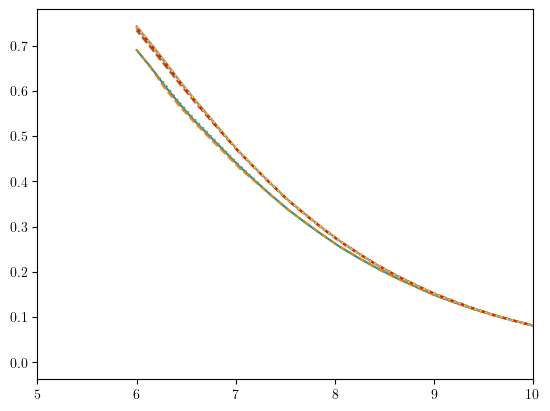

In [28]:
plt.plot(fnl0.node_redshifts,1-fnl0.global_quantities['xH_box'])
plt.plot(fnl100.node_redshifts,1-fnl100.global_quantities['xH_box'],'--')
plt.plot(fnlm100.node_redshifts,1-fnlm100.global_quantities['xH_box'],':')

plt.plot(fnl0_bigbox.node_redshifts,1-fnl0_bigbox.global_quantities['xH_box'])
plt.plot(fnl100_bigbox.node_redshifts,1-fnl100_bigbox.global_quantities['xH_box'],'--')
plt.plot(fnlm100_bigbox.node_redshifts,1-fnlm100_bigbox.global_quantities['xH_box'],':')

plt.plot(fnl0_smallbox.node_redshifts,1-fnl0_smallbox.global_quantities['xH_box'])
plt.plot(fnl100_smallbox.node_redshifts,1-fnl100_smallbox.global_quantities['xH_box'],'--')
plt.plot(fnlm100_smallbox.node_redshifts,1-fnlm100_smallbox.global_quantities['xH_box'],':')

plt.xlim(5,10)
